### Week 9 Question 2 Python 

In [2]:
import numpy as np         
import matplotlib.pyplot as plt  


---     

In [19]:
n =10
R = np.random.randn(n, n)      
A = R.T @ R                    
b = np.random.randn(n)       
x = np.linalg.solve(A, b) 

---    

### Q2(a) Steepest descent   

In [21]:
def my_sd_step(xm: np.ndarray, rm: np.ndarray, A: np.ndarray):
    Arm = A @ rm
    am = (rm @ rm) / (rm @ Arm)
    rk = rm - am * Arm
    xk = xm + am * rm
    return xk, rk

In [22]:
def my_sd_run(
    A: np.ndarray,
    b: np.ndarray,
    x_true: np.ndarray,
    x0: np.ndarray,
    ns: int,
):
    
    n = A.shape[0]

    xk = np.zeros((n, ns))
    rk = np.zeros((n, ns))
    re = np.zeros(ns)
    xe = np.zeros(ns)

    xk[:, 0] = x0
    rk[:, 0] = b - A @ x0
    re[0] = np.linalg.norm(rk[:, 0])
    xe[0] = np.linalg.norm(xk[:, 0] - x_true)

    for k in range(1, ns):
        xk[:, k], rk[:, k] = my_sd_step(xk[:, k - 1], rk[:, k - 1], A)
        re[k] = np.linalg.norm(rk[:, k])
        xe[k] = np.linalg.norm(xk[:, k] - x_true)

    return xk, rk, re, xe

In [23]:
ns = 11                                
x0 = np.zeros(n)                      
xkSD, rkSD, reSD, xeSD = my_sd_run(A, b, x, x0, ns)

---   

### Q2(b) Conjugate Gradient descent   

In [24]:
def cg_step(xm: np.ndarray, rm: np.ndarray, dm: np.ndarray, A: np.ndarray):
   
    Arm = A @ rm
    Adm = A @ dm
    alpha = (rm @ rm) / (dm @ Adm)
    rk = rm - alpha * Adm
    xk = xm + alpha * dm

    beta = (rk @ rk) / (rm @ rm)
    dk = rk + beta * dm

    return xk, rk, dk

---  

In [25]:
def cg_run(A: np.ndarray,
           b: np.ndarray,
           x_true: np.ndarray,
           x0: np.ndarray,
           ns: int):
   
    n = A.shape[0]
    xk = np.zeros((n, ns))
    rk = np.zeros((n, ns))
    dk = np.zeros((n, ns))
    re = np.zeros(ns)
    xe = np.zeros(ns)

    xk[:, 0] = x0
    rk[:, 0] = b - A @ x0
    dk[:, 0] = rk[:, 0].copy()         
    re[0] = np.linalg.norm(rk[:, 0])
    xe[0] = np.linalg.norm(xk[:, 0] - x_true)

    for k in range(1, ns):
        xk[:, k], rk[:, k], dk[:, k] = cg_step(
            xk[:, k - 1], rk[:, k - 1], dk[:, k - 1], A
        )
        re[k] = np.linalg.norm(rk[:, k])
        xe[k] = np.linalg.norm(xk[:, k] - x_true)

    return xk, rk, dk, re, xe

In [26]:
ns = 11                                
x0 = np.zeros(n)                       
xkCG, rkCG, dkCG, reCG, xeCG = cg_run(A, b, x, x0, ns)

### Q2(c) Residual and error  

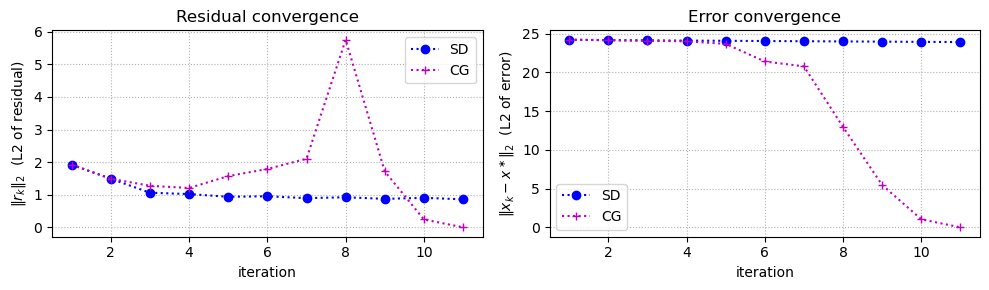

In [27]:

xx = np.arange(1, ns + 1)

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)                     
plt.plot(xx, reSD, "b:o", label="SD")    
plt.plot(xx, reCG, "m:+", label="CG")    
plt.xlabel("iteration")
plt.ylabel(r"$\|r_k\|_2$  (L2 of residual)")
plt.title("Residual convergence")
plt.legend()
plt.grid(True, which="both", ls=":")

plt.subplot(1, 2, 2)                   
plt.plot(xx, xeSD, "b:o", label="SD")
plt.plot(xx, xeCG, "m:+", label="CG")
plt.xlabel("iteration")
plt.ylabel(r"$\|x_k - x^\ast\|_2$  (L2 of error)")
plt.title("Error convergence")
plt.legend()
plt.grid(True, which="both", ls=":")

plt.tight_layout()

plt.show()
